In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1338
Columns : 7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.duplicated().sum()

np.int64(1)

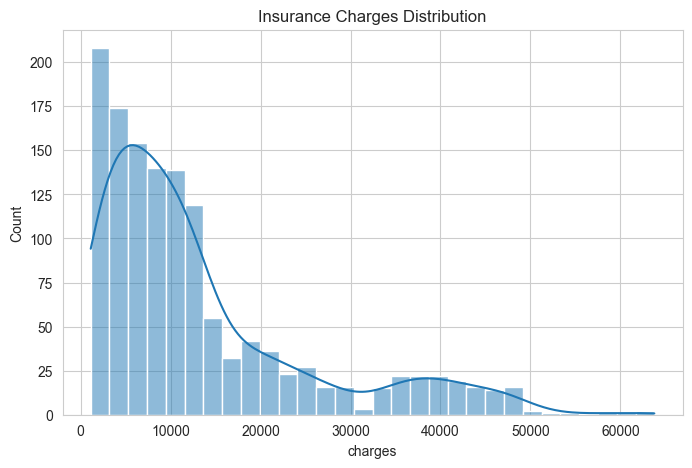

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Insurance Charges Distribution")

plt.show()

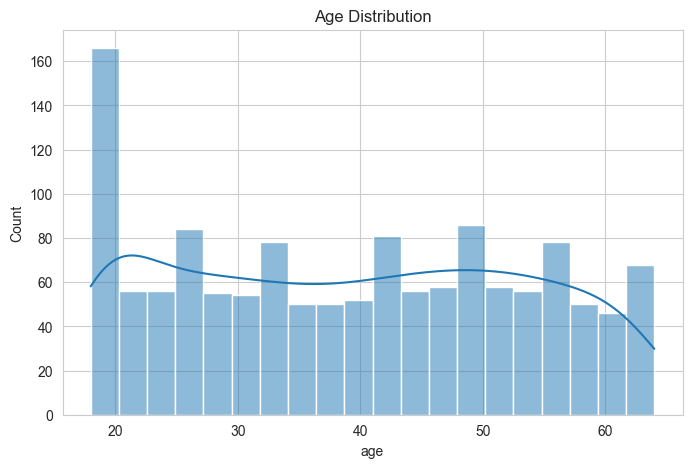

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

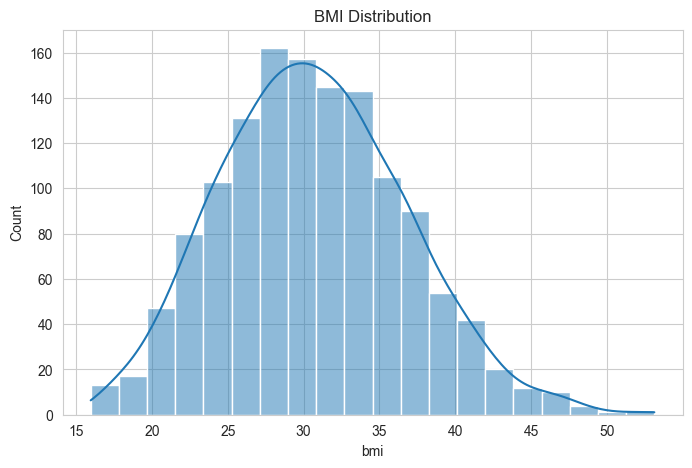

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["bmi"],
    bins=20,
    kde=True
)

plt.title("BMI Distribution")

plt.show()

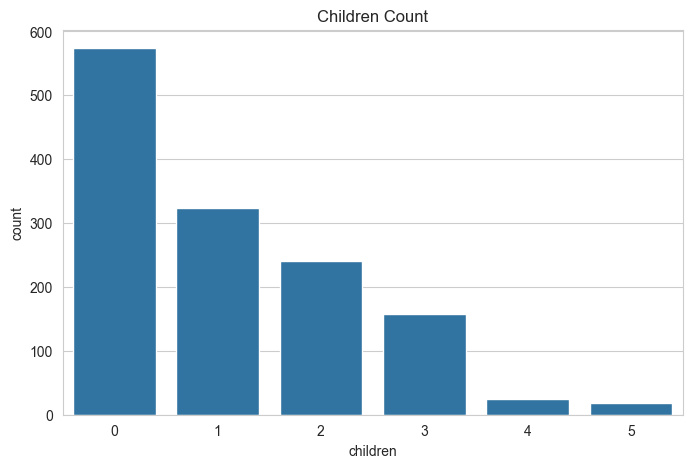

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="children",
    data=df
)

plt.title("Children Count")

plt.show()

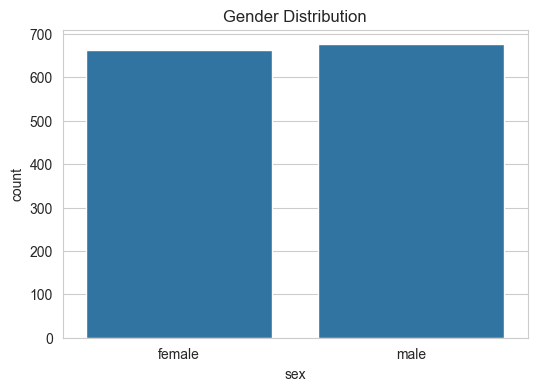

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sex",
    data=df
)

plt.title("Gender Distribution")

plt.show()

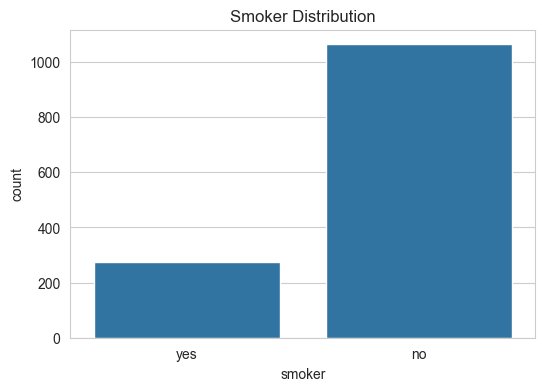

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="smoker",
    data=df
)

plt.title("Smoker Distribution")

plt.show()

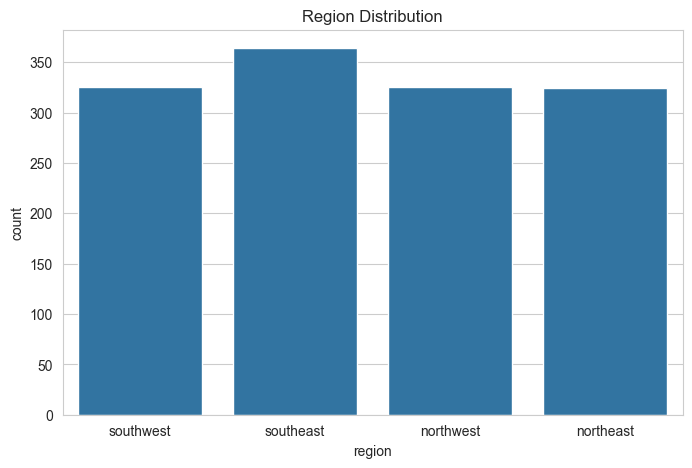

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="region",
    data=df
)

plt.title("Region Distribution")

plt.show()

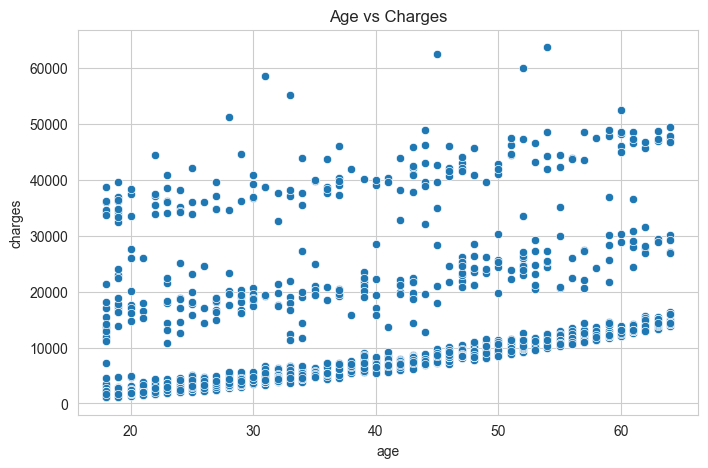

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.title("Age vs Charges")

plt.show()

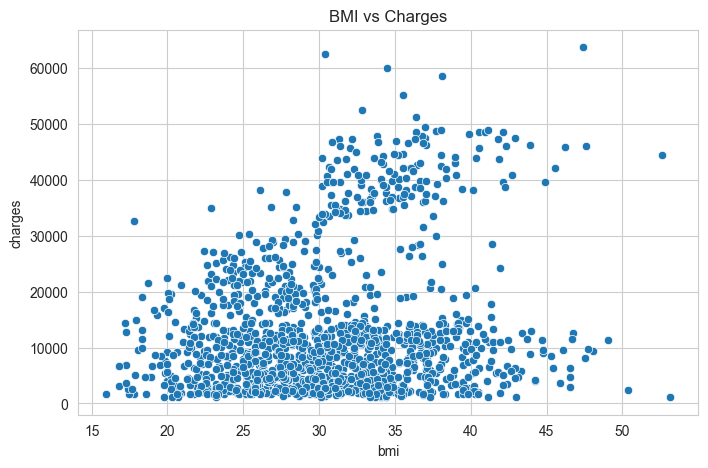

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="bmi",
    y="charges",
    data=df
)

plt.title("BMI vs Charges")

plt.show()

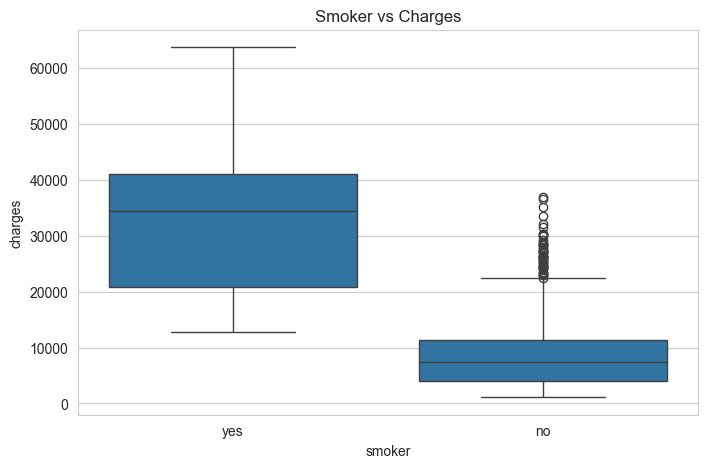

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)

plt.title("Smoker vs Charges")

plt.show()

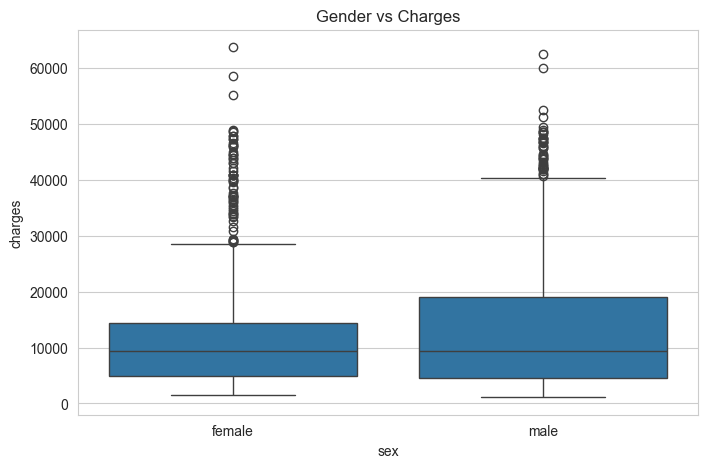

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="sex",
    y="charges",
    data=df
)

plt.title("Gender vs Charges")

plt.show()

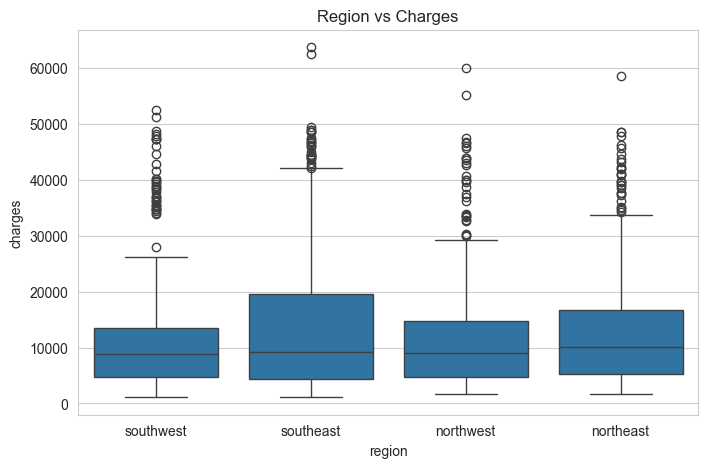

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="region",
    y="charges",
    data=df
)

plt.title("Region vs Charges")

plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


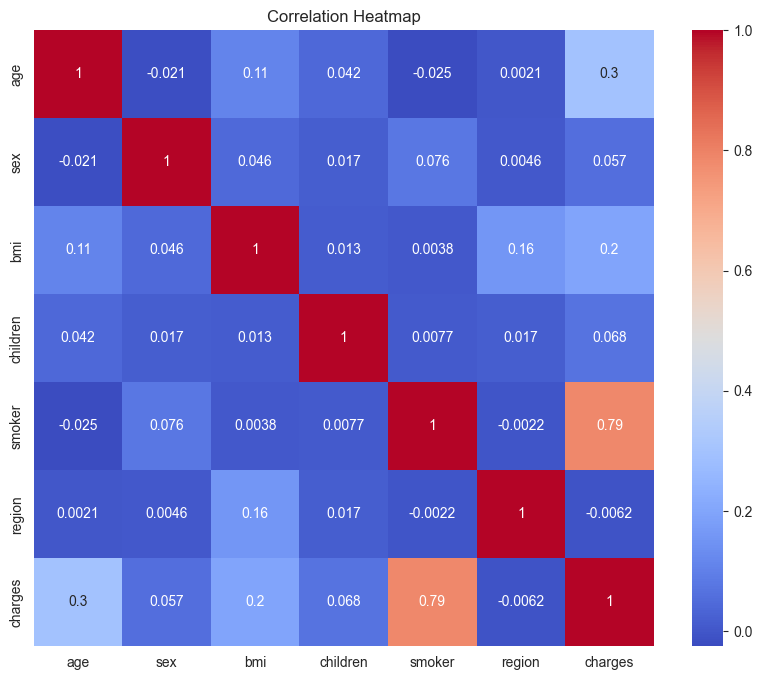

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

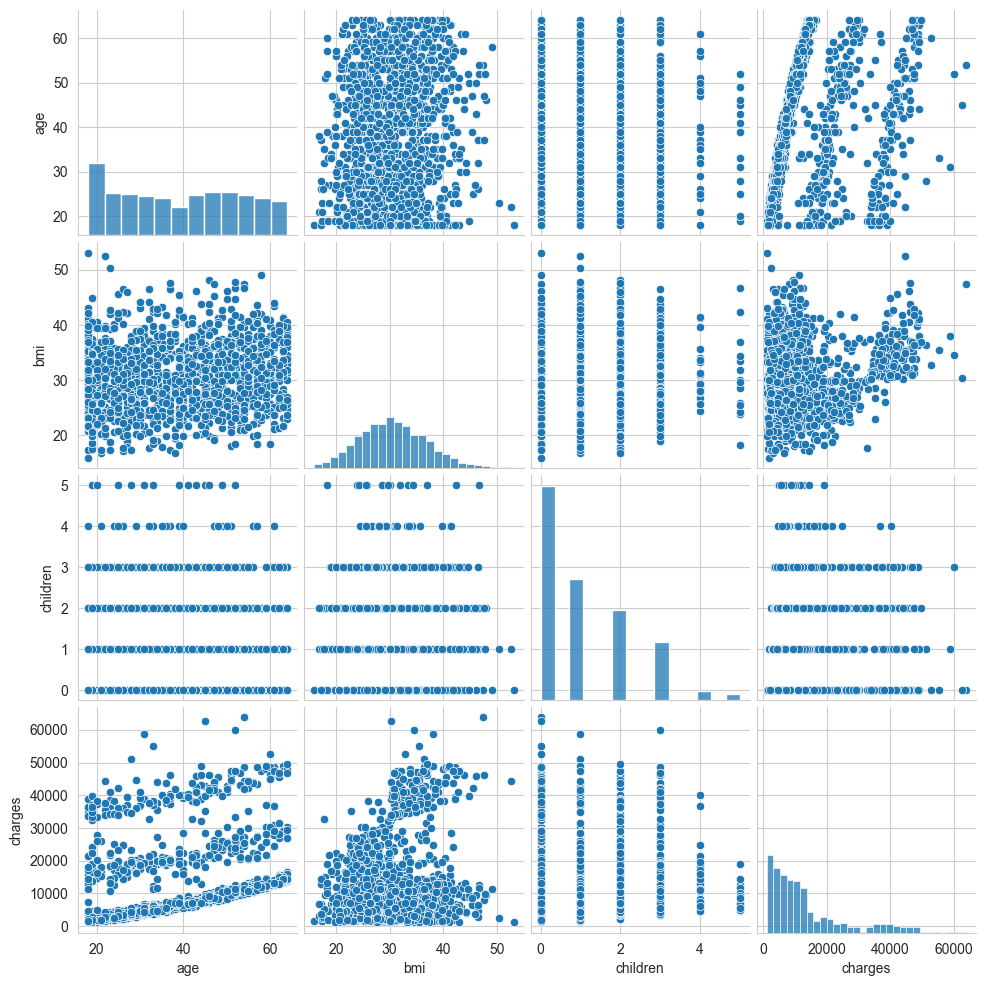

In [23]:
sns.pairplot(
    df_encoded[
        [
            "age",
            "bmi",
            "children",
            "charges"
        ]
    ]
)

plt.show()

In [24]:
corr = df_encoded.corr()["charges"].sort_values(
    ascending=False
)

corr

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64

In [25]:
print("""
1. Smokers have significantly higher insurance charges.
2. Age positively impacts insurance charges.
3. BMI shows moderate correlation with charges.
4. Children count has weak correlation.
5. Smoking status is one of the strongest predictors.
6. Charges distribution is right-skewed.
""")


1. Smokers have significantly higher insurance charges.
2. Age positively impacts insurance charges.
3. BMI shows moderate correlation with charges.
4. Children count has weak correlation.
5. Smoking status is one of the strongest predictors.
6. Charges distribution is right-skewed.

